# Simple Linear Regression (Single Feature)
* The Task: Find a simple dataset with one continuous feature and one target (e.g., predicting a student's test score based on hours studied).
* Objectives: 
* Split the data into training and testing sets.
* Use sklearn.linear_model.LinearRegression to train the model.
* Create a scatter plot of the test data and overlay the predicted line of best fit.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt 

# load the data
df = pd.read_csv("study_hour - study_hour.csv")
# df.head()
print("Available columns:", df.columns.tolist())

Available columns: ['Hours_Studied', 'Test_Score']


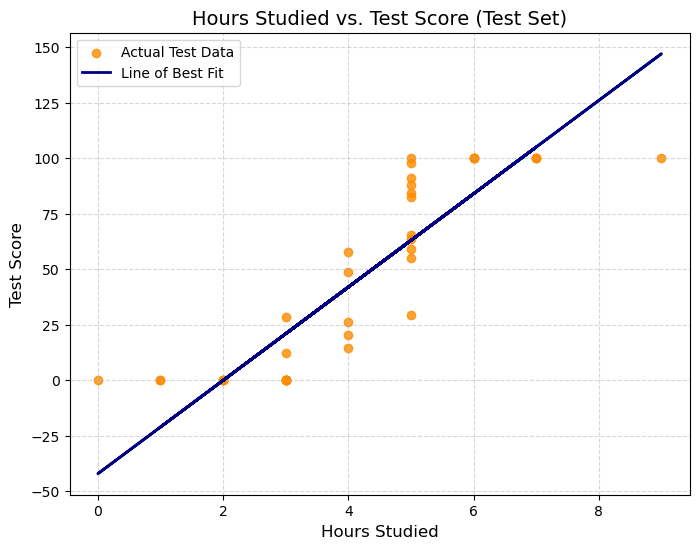

Slope (m): 21.02746121964062
Intercept/Bias (b): -42.22034426428699


In [53]:
# define X and y 
X = df[["Hours_Studied"]].values  
y = df["Test_Score"].values       

# using to split the data concept 80%_20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
model = LinearRegression()

# train model 80% of the data
model.fit(X_train, y_train)

# using 20% of data to test
y_pred = model.predict(X_test)  # calculte y = mx+b

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='darkorange', label='Actual Test Data', alpha=0.8)
plt.plot(X_test, y_pred, color='navy', linewidth=2, label='Line of Best Fit')
plt.title('Hours Studied vs. Test Score (Test Set)', fontsize=14)
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Test Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

m = model.coef_[0]
b = model.intercept_

print(f"Slope (m): {m}")
print(f"Intercept/Bias (b): {b}")

# Multiple Linear Regression & Feature Interpretation
* The Task: Use a multi-featured dataset like the California Housing Dataset.
* Objectives:
* Perform basic Exploratory Data Analysis (EDA) to check for correlations between features.
* Train a Multiple Linear Regression model.
* Extract and interpret the model's coefficients. Which features have the strongest positive or negative impact on the target variable?

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load the dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

df.head()
# print("Available columns:", df.columns.tolist())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


* Perform basic Exploratory Data Analysis (EDA) to check for correlations between features.

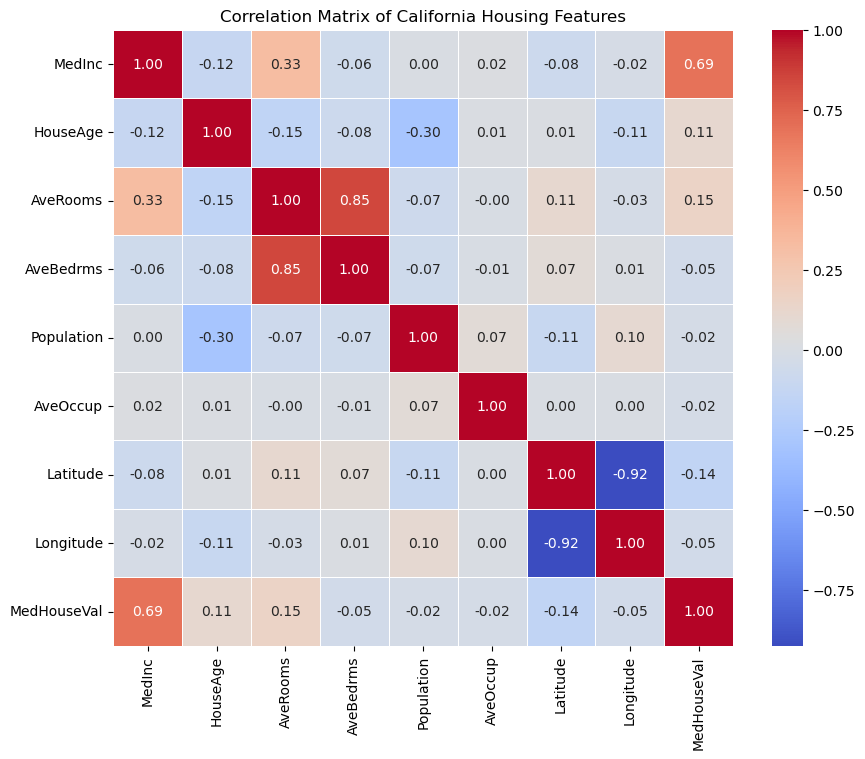

In [13]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of California Housing Features")
plt.show()

* Train a Multiple Linear Regression model.

In [21]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# 2. Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


* Extract and interpret the model's coefficients. Which features have the strongest positive or negative impact on the target variable?

In [22]:
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nModel Coefficients:")
print(coefficients_df)


Model Coefficients:
      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708
